In [1]:
from google.colab import files
upload = files.upload()


Saving online_gaming_behavior_dataset.csv.zip to online_gaming_behavior_dataset.csv.zip


   PlayerID  Age  Gender Location GameGenre  PlayTimeHours  InGamePurchases  \
0      9000   43    Male    Other  Strategy      16.271119                0   
1      9001   29  Female      USA  Strategy       5.525961                0   
2      9002   22  Female      USA    Sports       8.223755                0   
3      9003   35    Male      USA    Action       5.265351                1   
4      9004   33    Male   Europe    Action      15.531945                0   

  GameDifficulty  SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
0         Medium                6                        108           79   
1         Medium                5                        144           11   
2           Easy               16                        142           35   
3           Easy                9                         85           57   
4         Medium                2                        131           95   

   AchievementsUnlocked EngagementLevel  
0                   

/tmp/ipykernel_3260/4177516994.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


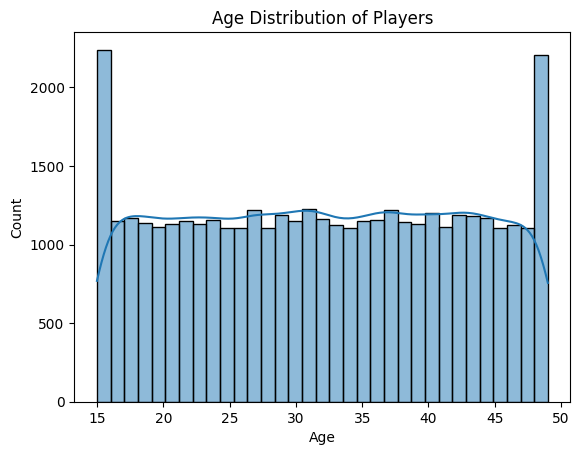

Observation: Most players fall within a specific age range, showing target audience concentration.


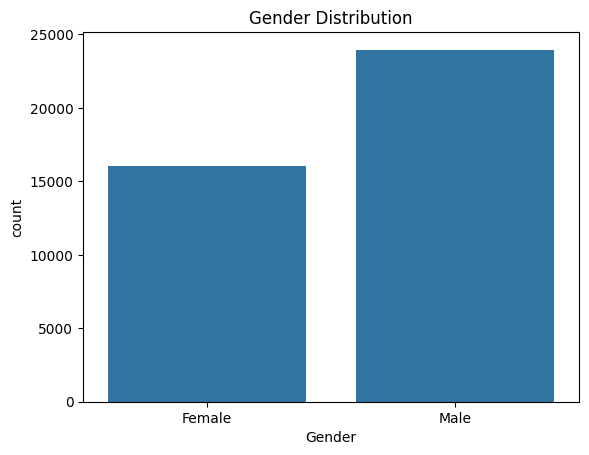

Observation: The dataset shows which gender dominates the gaming population.


KeyError: 'Hours_Played'

<Figure size 640x480 with 0 Axes>

In [2]:
# ===============================
# 📌 IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# ===============================
# 📌 LOAD DATA
# ===============================
# Unzip file
zip_file = "online_gaming_behavior_dataset.csv.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

# Load CSV
df = pd.read_csv("online_gaming_behavior_dataset.csv")

# Display first rows
print(df.head())

# ===============================
# 📌 BASIC INFO
# ===============================
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ===============================
# 📌 DATA CLEANING
# ===============================
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values (example)
df.fillna(method='ffill', inplace=True)

# ===============================
# 📌 DATA PREPROCESSING
# ===============================
# Convert categorical columns if needed
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

print("\nCleaned Data:")
print(df.head())

# ===============================
# 📊 VISUALIZATION 1: AGE DISTRIBUTION
# ===============================
plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Players")
plt.show()

print("Observation: Most players fall within a specific age range, showing target audience concentration.")

# ===============================
# 📊 VISUALIZATION 2: GENDER COUNT
# ===============================
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

print("Observation: The dataset shows which gender dominates the gaming population.")

# ===============================
# 📊 VISUALIZATION 3: HOURS PLAYED
# ===============================
plt.figure()
sns.histplot(df['Hours_Played'], kde=True)
plt.title("Hours Played Distribution")
plt.show()

print("Observation: Most users spend moderate hours gaming, while a few are heavy gamers.")

# ===============================
# 📊 VISUALIZATION 4: AGE VS HOURS PLAYED
# ===============================
plt.figure()
sns.scatterplot(x='Age', y='Hours_Played', data=df)
plt.title("Age vs Hours Played")
plt.show()

print("Observation: There is a relationship between age and gaming time.")

# ===============================
# 📊 VISUALIZATION 5: CORRELATION HEATMAP
# ===============================
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Observation: Some variables show strong correlation which can help in prediction.")

# ===============================
# 📌 FINAL CONCLUSION
# ===============================
print("\nFINAL CONCLUSION:")
print("""
1. The dataset shows clear gaming patterns based on age and time spent.
2. Certain age groups are more engaged in gaming.
3. Gaming duration varies significantly among users.
4. Correlation between features can help in predictive modeling.
5. Data is clean and suitable for further ML tasks.
""")